# Étape 1 : Chargement des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge

df = pd.read_csv("insurance-data.csv")

In [2]:
df.shape

(1338, 7)

# Étape 2 : Exploration des Données (EDA)

## 1) Aperçu de la structure des données

In [3]:
# Affichage des premières lignes et vérifier la structure du DataFrame
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [4]:
# Vérification des types de données et des valeurs manquantes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Aucune valeur manquante.

## 2) Statistiques descriptives 

### A) Variables numériques

In [5]:
# Calculer et afficher les statistiques descriptives du DataFrame
df.describe().round(0)

,age,bmi,children,expenses
count,1338.0,1338.0,1338.0,1338.0
mean,39.0,31.0,1.0,13270.0
std,14.0,6.0,1.0,12110.0
min,18.0,16.0,0.0,1122.0
25%,27.0,26.0,0.0,4740.0
50%,39.0,30.0,1.0,9382.0
75%,51.0,35.0,2.0,16640.0
max,64.0,53.0,5.0,63770.0


Quelles caractéristiques présentent la plus grande variation ? Cela pourrait-il indiquer des outliers ou des échelles différentes entre les variables ?

La variable expenses (frais médicaux, notre cible) présente de loin la plus grande variation, avec un écart d'environ 62 650 $ entre sa valeur minimale (1 122 $) et sa valeur maximale (63 770 $), et un écart-type d'environ 12 110 $. Cette variation s'explique d'abord par une différence d'échelle : charges s'exprime en milliers de dollars, alors que age, bmi et children sont des valeurs à deux chiffres au maximum. Cette différence d'échelle justifiera la standardisation des features avant l'entraînement des modèles sensibles aux distances comme KNN.

Au-delà de l'échelle, charges montre aussi des signes de valeurs extrêmes. L'écart-type est presque aussi élevé que la moyenne, et le maximum est près de 5 fois supérieur à la moyenne. Il ne s'agit pas forcément d'erreurs de saisie : ces valeurs élevées pourraient correspondre à un profil d'assurés à risque.

Les autres variables varient peu et restent dans des plages réalistes. L'âge est compris entre 18 et 64 ans et le nombre d'enfants entre 0 et 5. L'IMC va de 16 à 53 : le maximum correspond à une obésité sévère, qui reste plausible médicalement, et ne semble donc pas être une valeur aberrante.

Y a-t-il des caractéristiques avec des moyennes ou médianes très différentes ? Que cela pourrait-il signifier ?

Pour age (moyenne 39,2 contre médiane 39), bmi (30,7 contre 30,4) et children (1,09 contre 1), la moyenne et la médiane sont quasiment identiques. Ces distributions sont donc plutôt symétriques et peu affectées par des valeurs extrêmes.

En revanche, pour la variable cible expenses, la moyenne (13 270 $) est supérieure d'environ 41 % à la médiane (9 382 $). La distribution des frais médicaux est donc asymétrique à droite : la moitié des assurés a des frais inférieurs à 9 382 $, mais une minorité d'assurés aux frais très élevés (jusqu'à 63 770 $) tire la moyenne vers le haut.

### B) Variables catégorielles

In [6]:
# les statistiques descriptives des variables catégorielles
df.describe(include=['O'])

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


On constate une cohérence dans les données car nous disposons de 2 catégories pour les variables sex et smoker et 4 pour les régions. Aucune valeur manquante pour ces variables.

Ces informations sont utiles pour la modélisation :

- Encodage : la faible cardinalité des variables (2 à 4 modalités) rend le One-Hot Encoding adapté. Il générera 5 colonnes numériques, après suppression d'une modalité par variable pour éviter la redondance.

- Équilibre des classes : sex (50,5 % d'hommes) et region (27,2 % pour la région la plus représentée, le sud-est) sont équilibrées. En revanche, smoker est déséquilibré avec 79,5 % de non-fumeurs. Ce déséquilibre justifiera une division stratifiée des données (stratify) pour conserver la même proportion de fumeurs dans les jeux d'entraînement et de test.

## 3) Distribution des Caractéristiques

### A) Variables numériques 

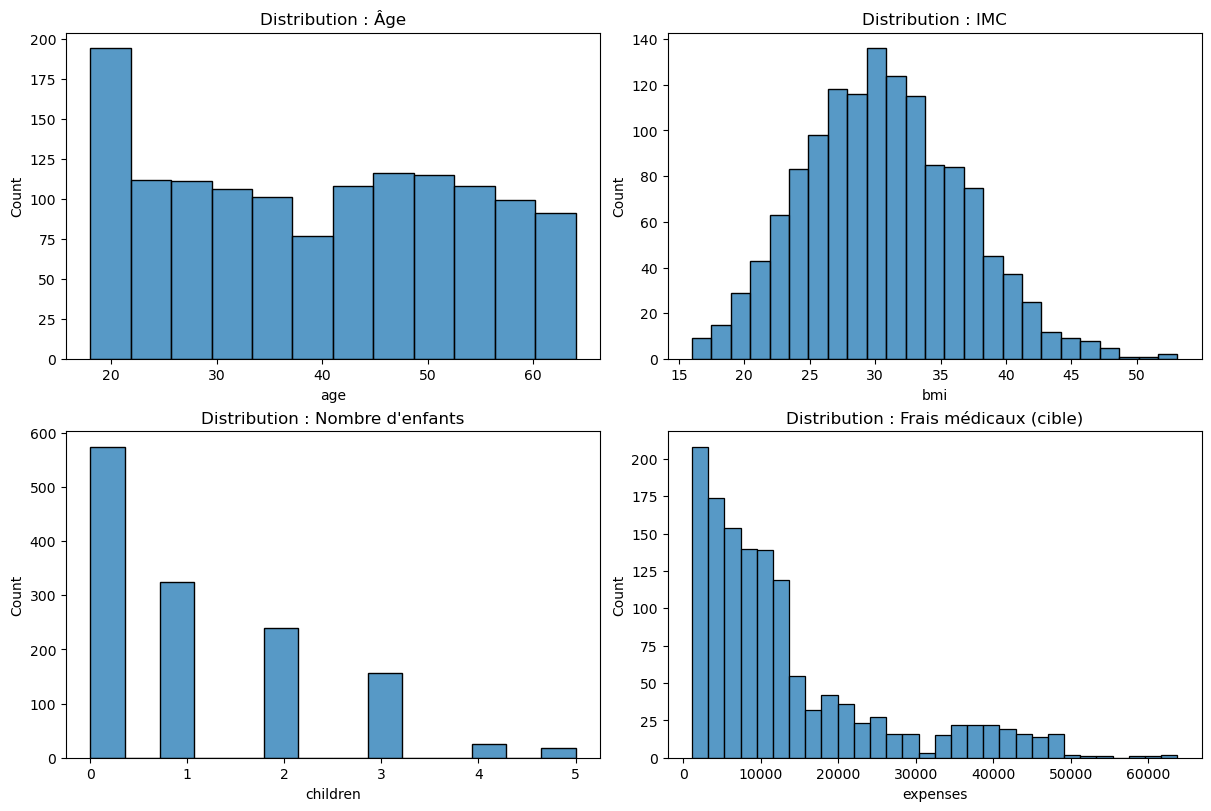

In [7]:
# Visualisation de la distribution des 4 variables numériques
# sur une même figure, organisée en grille de 2 lignes x 2 colonnes avec une boucle : on parcourt les variables et les cases de la grille en parallèle
colonnes = ["age", "bmi", "children", "expenses"]
titres = ["Âge", "IMC", "Nombre d'enfants", "Frais médicaux (cible)"]

fig, axs = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")

for col, titre, ax in zip(colonnes, titres, axs.flat):
    sns.histplot(df[col], ax=ax)
    ax.set_title(f"Distribution : {titre}")

plt.show()

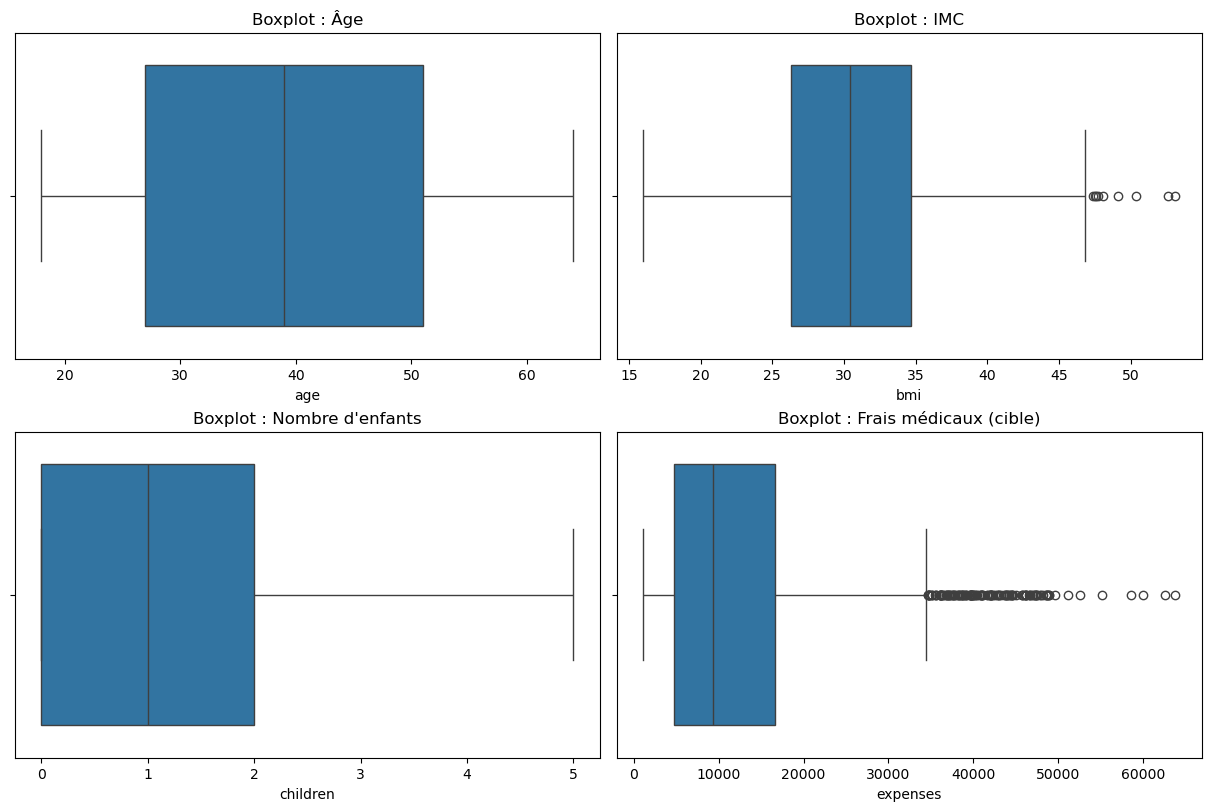

In [8]:
# Boxplots des 4 variables numériques sur une même figure (grille 2 x 2)
# pour repérer les valeurs extrêmes (points au-delà des moustaches)
colonnes = ["age", "bmi", "children", "expenses"]
titres = ["Âge", "IMC", "Nombre d'enfants", "Frais médicaux (cible)"]

fig, axs = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")

for col, titre, ax in zip(colonnes, titres, axs.flat):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Boxplot : {titre}")

plt.show()

La distribution de l'IMC (bmi) semble obéir à la loi normale centrée autour de 30. Celle de l'âge est symétrique alors que celles des enfants et des frais médicaux (expenses) sont asymétriques positivement (à droite): la majorité des valeurs se concentre vers le bas, avec une longue queue de valeurs élevées plus rares.

C'est surtout l'asymétrie de la cible expenses qui peut influencer la performance du modèle. Les frais élevés étant peu nombreux, le modèle dispose de peu d'exemples pour apprendre à les prédire et risque de les sous-estimer. La variable children est asymétrique mais ne prend que 6 valeurs entières, son impact devrait donc être limité.

Les frais médicaux contiennent beaucoup de valeurs extrêmes (au-dessus de 35K$). Cela ne semble pas être des erreurs de saisie car on comprend que les frais médicaux puissent être très élevés pour certaines pathologies.
L'IMC contient également quelques valeurs extrêmes avec des IMC comprises en 47 et 55. Cela ne correspond pas à des erreurs de saisie car cela correspond à des poids compris entre 136 et 135kg. Cela est très plausible, notamment aux Etats-Unis.

La variable expenses contient de nombreuses valeurs extrêmes, au-delà d'environ 34K$. Il ne s'agit pas d'erreurs de saisie : des frais médicaux très élevés sont plausibles pour certains profils à risque ou certaines pathologies. L'IMC présente aussi quelques valeurs extrêmes, entre 47 et 53 environ. Elles correspondent à une obésité sévère (par exemple 136 à 153 kg pour une personne de 1,70 m), médicalement plausible, et ne constituent donc pas non plus des erreurs.

Ces valeurs extrêmes peuvent affecter l'entraînement de certains modèles. La régression linéaire, qui minimise l'erreur au carré, et le KNN, basé sur les distances, y sont sensibles : quelques valeurs extrêmes peuvent fortement modifier leurs prédictions. Les modèles à base d'arbres (Decision Tree, Random Forest) y sont plus robustes car ils raisonnent par seuils successifs. On ne supprimera pas ces valeurs : dans un contexte de tarification, les assurés aux frais élevés sont justement ceux que le modèle doit savoir identifier.

### B) Variables catégorielles

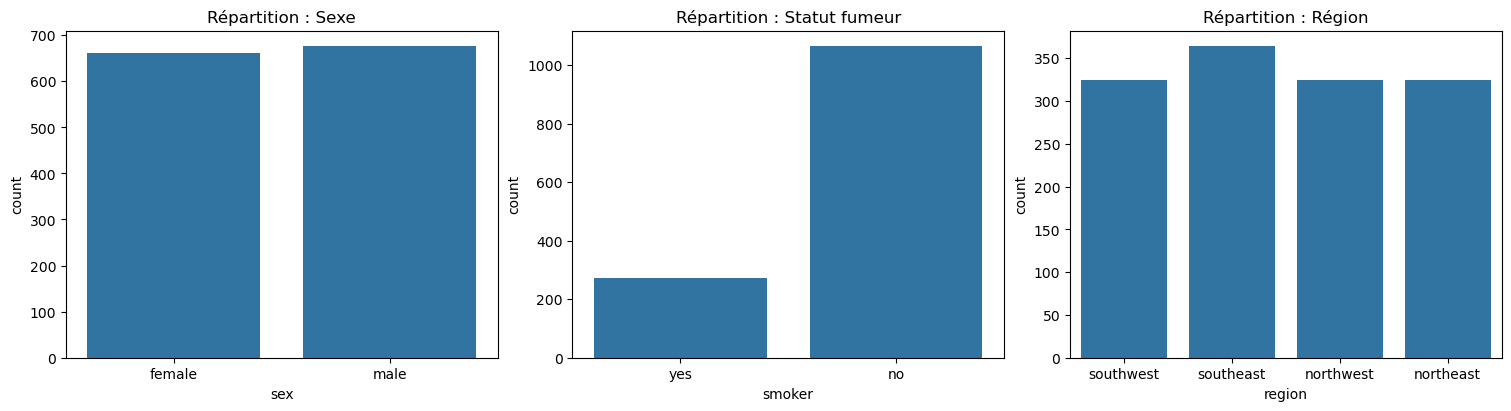

In [9]:
# Répartition des assurés selon chaque variable catégorielle
# pour vérifier si les groupes sont équilibrés
colonnes_cat = ["sex", "smoker", "region"]
titres_cat = ["Sexe", "Statut fumeur", "Région"]

fig, axs = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")

for col, titre, ax in zip(colonnes_cat, titres_cat, axs):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"Répartition : {titre}")

plt.show()

- Sexe : la répartition entre hommes et femmes est quasiment équilibrée, autour de 50 % chacun. Le modèle disposera d'autant d'exemples pour les deux groupes.

- Statut fumeur : la répartition est nettement déséquilibrée. Les non-fumeurs représentent environ 80 % des assurés, contre 20 % pour les fumeurs.

- Région : les quatre régions sont bien représentées. Le sud-est est légèrement plus représenté. Cet écart reste faible et ne devrait pas biaiser le modèle.

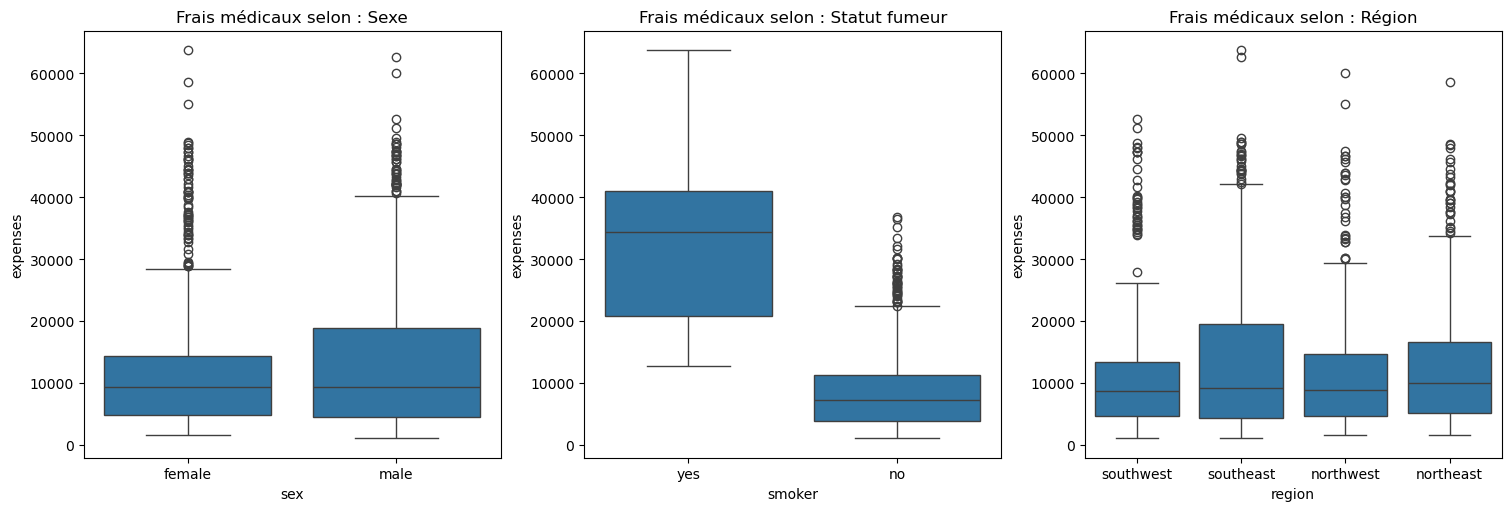

In [10]:
# Comparaison de la distribution des frais médicaux
# selon chaque variable catégorielle
colonnes_cat = ["sex", "smoker", "region"]
titres_cat = ["Sexe", "Statut fumeur", "Région"]

fig, axs = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")

for col, titre, ax in zip(colonnes_cat, titres_cat, axs):
    sns.boxplot(data=df, x=col, y="expenses", ax=ax)
    ax.set_title(f"Frais médicaux selon : {titre}")

plt.show()

In [11]:
# Frais médians et moyens par modalité, pour chiffrer
# l'impact de chaque variable catégorielle sur la cible
for col in ["sex", "smoker", "region"]:
    print(df.groupby(col)["expenses"].agg(["median", "mean", "count"]), "\n")

          median          mean  count
sex                                  
female  9412.965  12569.578897    662
male    9369.615  13956.751420    676 

           median          mean  count
smoker                                
no       7345.405   8434.268449   1064
yes     34456.350  32050.231971    274 

              median          mean  count
region                                   
northeast  10057.655  13406.384691    324
northwest   8965.800  12417.575169    325
southeast   9294.130  14735.411538    364
southwest   8798.590  12346.937908    325 



- Statut fumeur : c'est la variable catégorielle la plus influente. Les distributions des fumeurs et des non-fumeurs ne se chevauchent presque pas : les frais médians des fumeurs (environ 35K) sont environ 5 fois supérieurs à ceux des non-fumeurs (environ 7K).

- Sexe : l'impact est faible. Les frais médians sont quasiment identiques pour les hommes et les femmes (environ 10K). Les frais des hommes sont toutefois plus dispersés vers le haut, ce qui pourrait s'expliquer par une proportion de fumeurs plus élevée chez les hommes.

 - Région : l'impact est également faible. Les frais médians sont proches d'une région à l'autre (entre 9K et 10K). Le sud-est présente une dispersion plus importante vers les frais élevés, qui pourrait s'expliquer par un IMC moyen plus élevé ou une proportion de fumeurs plus importante dans cette région.


Dans tous les groupes, les valeurs extrêmes au-delà de 30K semblent correspondre aux fumeurs. Le statut fumeur reste donc le facteur déterminant, quels que soient le sexe ou la région.

## 4) Analyse de la corrélation

<Axes: >

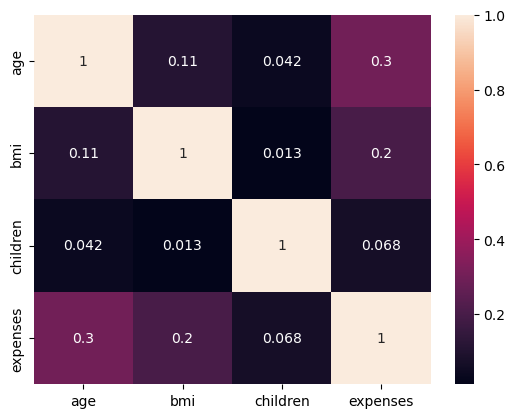

In [12]:
# Calculer et visualiser la matrice de corrélation
sns.heatmap(df.corr(method='pearson',  min_periods=1, numeric_only=True),annot=True)

- Corrélations les plus fortes : Notre cible frais médicaux (expenses) semble corrélée positivement mais de façon modérée avec l age (+0.3) et l'imc (+0.2). Les frais ont donc tendance à augmenter avec l'âge et la corpulence.

- Corrélations les plus faibles : on remarque une corrélation faible entre l'âge et l imc  (+0.11). Il n'y a donc pas de redondance entre ces deux variables, et on peut les conserver toutes les deux.

- Corrélations proches de 0 : aucun lien ne se dessine entre notre cible et le nombre d enfants (+0.068).

## 5) Relation entre les Caractéristiques et la Cible

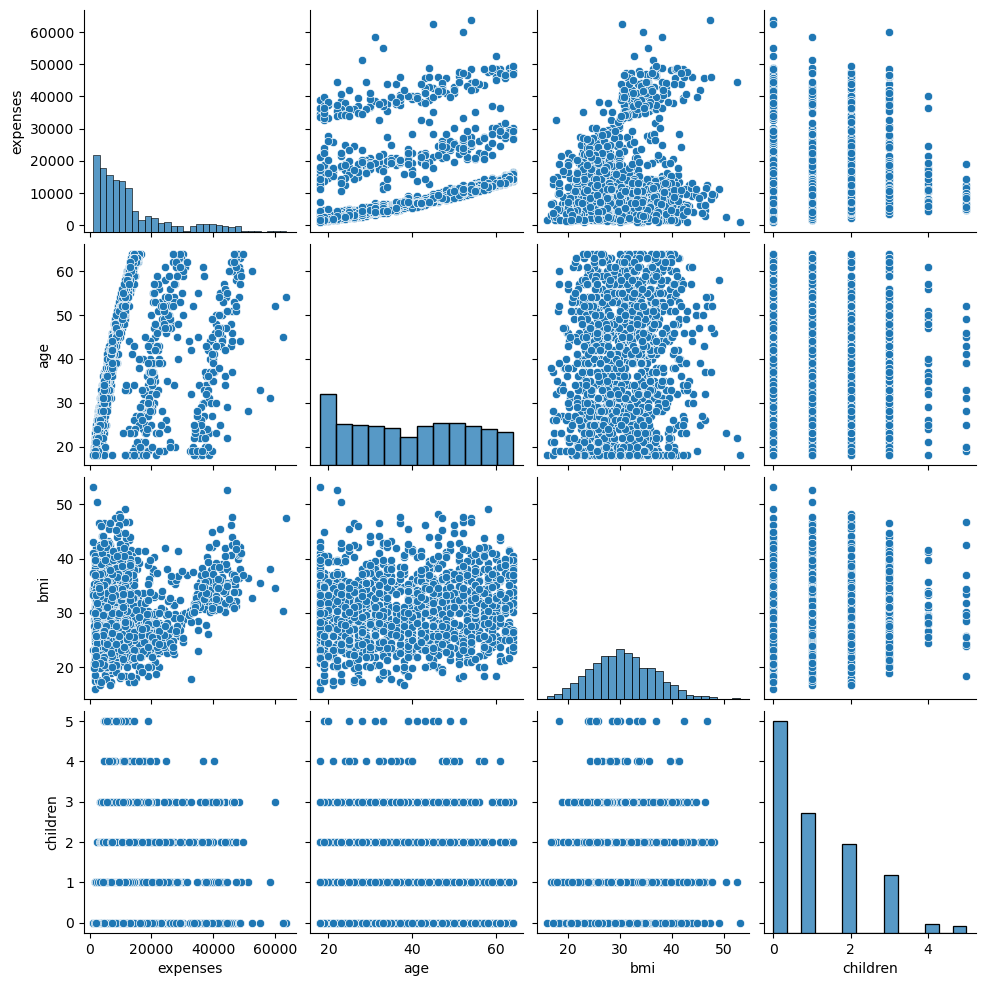

In [13]:
sns.pairplot(df[["expenses", "age", "bmi", "children"]])

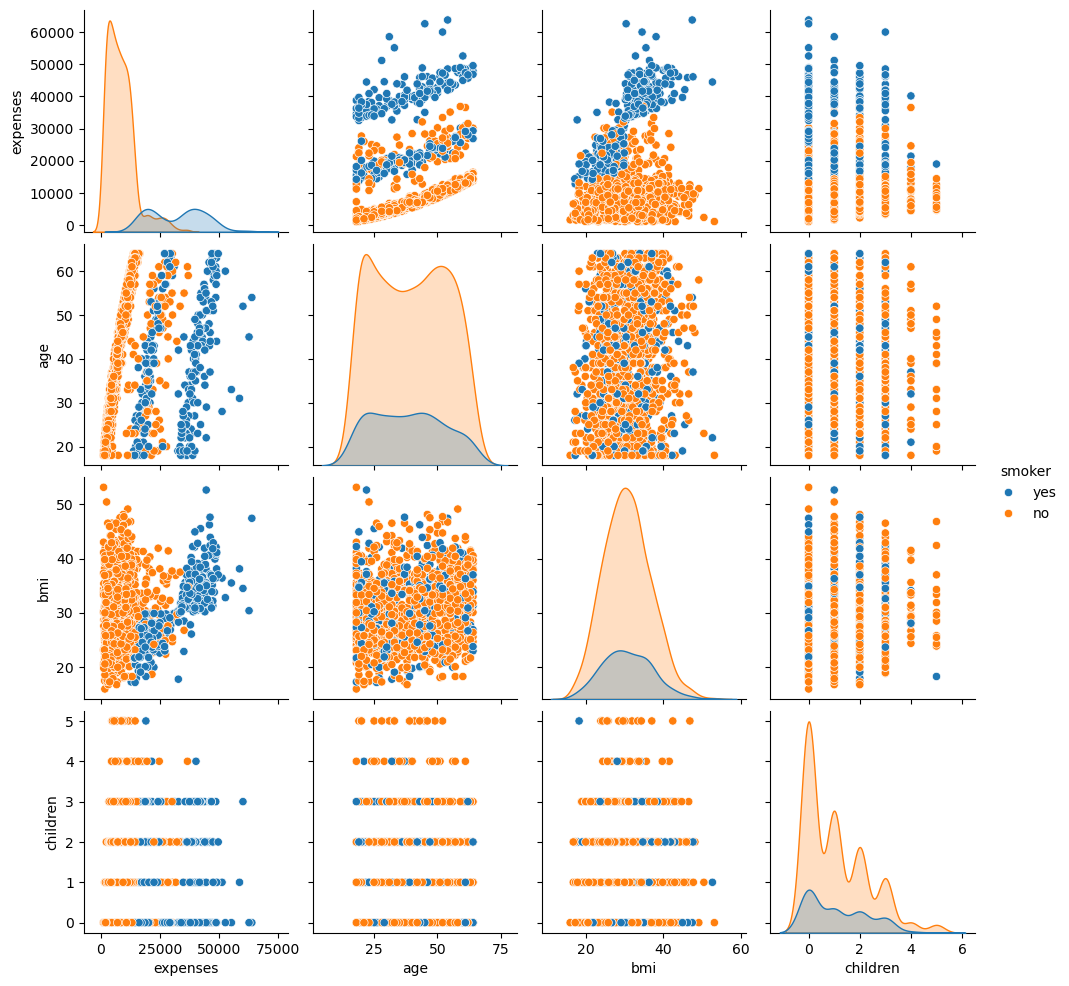

In [14]:
# Pairplot des variables numériques pour visualiser les relations
# entre chaque paire de variables et avec la cible (expenses).
# Le statut fumeur est utilisé comme couleur pour voir son influence.
sns.pairplot(df[["expenses", "age", "bmi", "children", "smoker"]], hue="smoker")
plt.show()

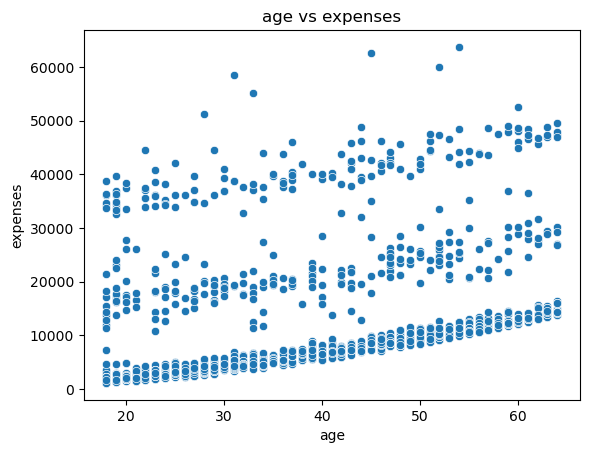

In [15]:
# Relation entre les frais médicaux et l'âge
sns.scatterplot(data=df, x="age", y="expenses")
plt.title("age vs expenses")
plt.show()

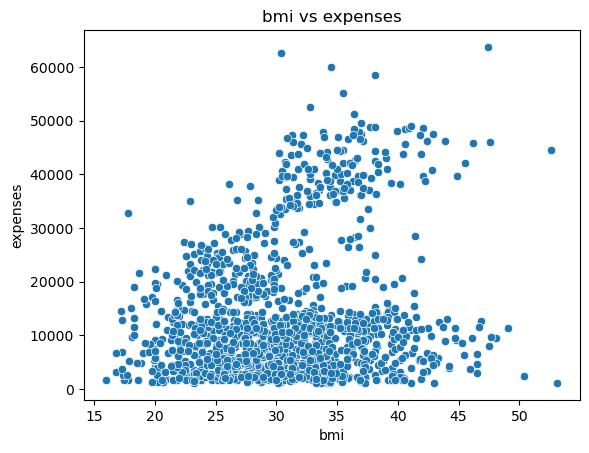

In [16]:
# Relation entre les frais médicaux et l'imc
sns.scatterplot(data=df, x="bmi", y="expenses")
plt.title("bmi vs expenses")
plt.show()

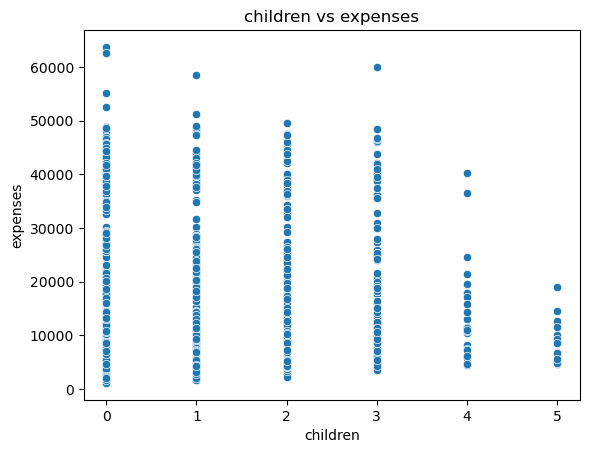

In [17]:
# Relation entre les frais médicaux et le nombre d enfants
sns.scatterplot(data=df, x="children", y="expenses")
plt.title("children vs expenses")
plt.show()

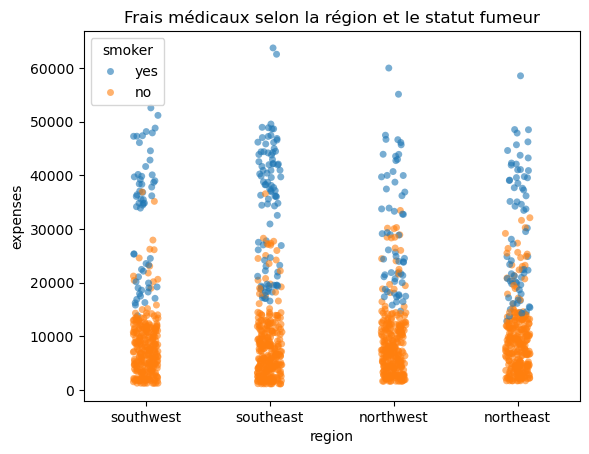

In [18]:
# Frais médicaux de chaque assuré selon la région,
# avec les points légèrement étalés pour éviter qu'ils se superposent
sns.stripplot(data=df, x="region", y="expenses", hue="smoker", alpha=0.6)
plt.title("Frais médicaux selon la région et le statut fumeur")
plt.show()

- Histogramme de expenses : La distribution est fortement asymétrique à droite : la grande majorité des frais se situe sous 15K. On distingue aussi une seconde bosse vers 35K à 45K. Cela suggère la présence de deux populations distinctes dans les données.

- Âge vs frais : Les points forment trois bandes parallèles qui montent avec l'âge. Il y a donc une relation linéaire positive entre l'âge et les frais, mais elle se répète à trois niveaux différents. Cette structure en bandes révèle qu'une autre variable, absente du graphique, sépare les assurés en groupes.

- IMC vs frais : La majorité des points forme un nuage sans tendance nette sous 15K. En revanche, un groupe se détache au-dessus de 30K, uniquement pour des IMC supérieurs à environ 30. Cela évoque un effet de seuil : au-delà de ce niveau d'IMC, certains assurés voient leurs frais bondir.

- Enfants vs frais : Pas de tendance observée : les frais se répartissent de la même façon quel que soit le nombre d'enfants. Les colonnes 4 et 5 sont moins remplies simplement parce que peu d'assurés ont autant d'enfants.

# Étape 3 : Prétraitement des Données

## 1) Vérification des doublons

In [19]:
# Vérification des doublons
df.duplicated().sum()

np.int64(1)

In [20]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,expenses
581,19,male,30.6,0,no,northwest,1639.56


In [21]:
# Suppression du doublon
df = df.drop_duplicates()

In [22]:
# pour vérifier qu on est passé à 1337 lignes
df.shape

(1337, 7)

## 2) Vérification et Traitement des Valeurs Manquantes

In [23]:
# Identifier les valeurs manquantes
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

## 3) Encodage des Variables Catégorielles

 **Encodage One-Hot** 

In [24]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
expenses    float64
dtype: object

Le dataset contient trois variables catégorielles (sex, smoker, region), qui doivent être encodées pour être utilisables par les modèles. Nous utilisons un encodage One-Hot (pd.get_dummies), qui crée une colonne 0/1 par modalité. Il est adapté car aucune de ces variables n'a d'ordre naturel : un encodage par numéros imposerait un ordre artificiel entre les régions. Cet encodage ne calcule aucune statistique sur les données : il peut donc être appliqué avant la division sans risque de fuite de données.

In [25]:
# Encodage One-Hot des variables catégorielles : une colonne 0/1 par modalité.
# drop_first=True supprime une modalité par variable, car elle se déduit des autres
# (ex. : si smoker_yes = 0, l'assuré est non-fumeur). Cela évite la redondance.
df_encoded = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True, dtype=int)
df_encoded.head()

,age,bmi,children,expenses,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,16884.92,0,1,0,0,1
1,18,33.8,1,1725.55,1,0,0,1,0
2,28,33.0,3,4449.46,1,0,0,1,0
3,33,22.7,0,21984.47,1,0,1,0,0
4,32,28.9,0,3866.86,1,0,1,0,0


# Étape 4 : Sélection des Variables, Division des Données et Prétraitement

## 1) Sélection des Variables Pertinentes

Toutes les caractéristiques sont conservées : l'EDA n'a montré aucune redondance entre elles, et même les variables à faible impact (sexe, région, enfants) peuvent apporter une information utile en combinaison avec les autres.

## 2) Séparation des Caractéristiques (Features) et de la Cible (Target)

In [26]:
# Séparation des caractéristiques (X) et la cible (y)
X = df_encoded[["age", "bmi", "children", "sex_male", "smoker_yes", "region_northwest", "region_southeast", "region_southwest"]]
y = df_encoded["expenses"]

## 3) Division des Données en Ensembles d’Entraînement et de Test

In [27]:
# Division des données : 80 % pour l'entraînement, 20 % pour le test.
# stratify garantit la même proportion de fumeurs (environ 20 %) dans les deux jeux, car cette variable est déséquilibrée et très influente.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=X["smoker_yes"])

*Remarque* : Le statut fumeur étant déséquilibré (20 % de fumeurs) et fortement lié aux frais médicaux, la division est stratifiée sur cette variable pour garantir une proportion identique de fumeurs dans les jeux d'entraînement et de test, et donc une évaluation fiable.

In [28]:
X_train.shape

(1069, 8)

In [29]:
y_train.shape

(1069,)

In [30]:
X_test.shape

(268, 8)

In [31]:
y_test.shape

(268,)

## 4) Prétraitement des Données

**Normalisation ou Standardisation des Données**

In [32]:
# Standardisation des variables numériques uniquement (moyenne 0, écart-type 1).
# fit_transform sur le train (apprentissage de la moyenne et de l'écart-type),
# transform seul sur le test, pour éviter toute fuite de données.
variables_num = ["age", "bmi", "children"]
scaler_std = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[variables_num] = scaler_std.fit_transform(X_train[variables_num])
X_test_scaled[variables_num] = scaler_std.transform(X_test[variables_num])

X_train_scaled.describe().round(2)

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
count,1069.00,1069.00,1069.00,1069.00,1069.0,1069.00,1069.00,1069.00
mean,-0.00,-0.00,-0.00,0.51,0.2,0.24,0.27,0.24
std,1.00,1.00,1.00,0.50,0.4,0.43,0.45,0.43
min,-1.50,-2.44,-0.92,0.00,0.0,0.00,0.00,0.00
25%,-0.93,-0.73,-0.92,0.00,0.0,0.00,0.00,0.00
50%,-0.00,-0.05,-0.08,1.00,0.0,0.00,0.00,0.00
75%,0.85,0.65,0.77,1.00,0.0,0.00,1.00,0.00
max,1.78,3.66,3.31,1.00,1.0,1.00,1.00,1.00


# Étape 5 : Entraînement des Modèles de Régression

## Modèle 1 : Régression linéaire

In [33]:
# Instanciation et entraînement de la régression linéaire sur les données standardisées.
# Le modèle cherche la combinaison linéaire des caractéristiques qui prédit le mieux les frais médicaux.
modele_lr = LinearRegression()
modele_lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Modèle 2 : K-Nearest Neighbors (KNN) en Régression

In [34]:
# Instanciation et entraînement du KNN (5 voisins par défaut) :
# les frais d'un assuré sont prédits par la moyenne des frais des 5 assurés les plus proches en caractéristiques
modele_knn = KNeighborsRegressor()
modele_knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Modèle 3 : Régression avec Arbre de Décision (Decision Tree Regressor)

In [35]:
# Instanciation et entraînement de l'arbre de décision, sans limite de profondeur.
# Le modèle découpe les données par seuils successifs 
modele_tree = DecisionTreeRegressor(random_state=42)
modele_tree.fit(X_train_scaled, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Modèle 4 : Forêt d'Arbres Décisionnels en Régression (Random Forest Regressor)

In [36]:
# Instanciation et entraînement de la forêt aléatoire (100 arbres par défaut).
# Elle fait la moyenne des prédictions de nombreux arbres entraînés sur des sous-échantillons différents, ce qui limite le surapprentissage.
modele_rf = RandomForestRegressor(random_state=42)
modele_rf.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Étape 6 : Prédiction avec les Modèles

In [37]:
# Prédiction des frais médicaux sur le jeu de test avec chacun des 5 modèles.
# Les modèles n'ont jamais vu ces assurés pendant l'entraînement.
y_pred_lr = modele_lr.predict(X_test_scaled)
y_pred_knn = modele_knn.predict(X_test_scaled)
y_pred_tree = modele_tree.predict(X_test_scaled)
y_pred_rf = modele_rf.predict(X_test_scaled)

In [38]:
# Regroupement des frais réels (y_test) et des frais prédits par chaque modèle dans un même tableau
comparaison = pd.DataFrame({
    "y_test": y_test,
    "y_pred_lr": y_pred_lr,
    "y_pred_knn": y_pred_knn,
    "y_pred_tree": y_pred_tree,
    "y_pred_rf": y_pred_rf,
})

comparaison.head(10).round(0)

,y_test,y_pred_lr,y_pred_knn,y_pred_tree,y_pred_rf
575,12223.0,11886.0,14808.0,12224.0,12762.0
932,10097.0,10556.0,10857.0,14478.0,11547.0
956,42000.0,35339.0,32614.0,42304.0,43456.0
144,20746.0,30587.0,20996.0,19933.0,23043.0
684,4766.0,2566.0,5033.0,21984.0,8383.0
633,7173.0,7146.0,12123.0,6600.0,8629.0
614,1880.0,3247.0,3895.0,1878.0,5429.0
1101,11253.0,12021.0,9383.0,25993.0,11738.0
702,9504.0,14248.0,11480.0,11094.0,13882.0
969,8597.0,11672.0,7412.0,8582.0,11752.0


In [39]:
comparaison["ecart_lr"] = comparaison["y_test"] - comparaison["y_pred_lr"]
comparaison["ecart_knn"] = comparaison["y_test"] - comparaison["y_pred_knn"]
comparaison["ecart_tree"] = comparaison["y_test"] - comparaison["y_pred_tree"]
comparaison["ecart_rf"] = comparaison["y_test"] - comparaison["y_pred_rf"]

comparaison.head(10).round(0)

,y_test,y_pred_lr,y_pred_knn,y_pred_tree,y_pred_rf,ecart_lr,ecart_knn,ecart_tree,ecart_rf
575,12223.0,11886.0,14808.0,12224.0,12762.0,337.0,-2585.0,-1.0,-539.0
932,10097.0,10556.0,10857.0,14478.0,11547.0,-459.0,-760.0,-4381.0,-1450.0
956,42000.0,35339.0,32614.0,42304.0,43456.0,6661.0,9385.0,-304.0,-1457.0
144,20746.0,30587.0,20996.0,19933.0,23043.0,-9841.0,-250.0,813.0,-2297.0
684,4766.0,2566.0,5033.0,21984.0,8383.0,2200.0,-267.0,-17218.0,-3617.0
633,7173.0,7146.0,12123.0,6600.0,8629.0,27.0,-4950.0,573.0,-1456.0
614,1880.0,3247.0,3895.0,1878.0,5429.0,-1367.0,-2015.0,2.0,-3549.0
1101,11253.0,12021.0,9383.0,25993.0,11738.0,-767.0,1870.0,-14739.0,-485.0
702,9504.0,14248.0,11480.0,11094.0,13882.0,-4743.0,-1976.0,-1589.0,-4378.0
969,8597.0,11672.0,7412.0,8582.0,11752.0,-3075.0,1184.0,15.0,-3155.0


Globalement, les prédictions suivent l'ordre de grandeur des frais réels, mais la précision varie fortement d'un modèle à l'autre. L'arbre de décision alterne entre des prédictions quasi exactes (écarts inférieurs à 20) et des erreurs très importantes (jusqu'à 17K). Le Random Forest présente des écarts plus réguliers et modérés, sans erreur extrême. La régression linéaire et le KNN ont des écarts intermédiaires, avec quelques erreurs importantes.

Sur ces 10 observations, le Random Forest semble le plus fiable : aucune de ses erreurs ne dépasse 4K. L'arbre de décision est parfois plus précis, mais ses grosses erreurs ponctuelles suggèrent un surapprentissage, lié à l'absence de limite de profondeur. 

Les frais élevés semblent plus difficiles à prédire pour la régression linéaire et le KNN : pour l'assuré aux frais de 42K, ils sous-estiment de 7K et 9K. Cela rejoint l'EDA : les frais élevés correspondent principalement aux fumeurs, peu nombreux (20 %), et à des effets de seuil (IMC supérieur à 30) que ces modèles capturent mal. À l'inverse, l'arbre de décision commet ses plus grosses erreurs sur des frais modestes, qu'il surestime fortement.

# Étape 7 : Interprétation des Modèles de Régression

## 1) Régression Linéaire : Interprétation des Coefficients

In [40]:
# affichage des coefficients de la régression linéaire
print("Coefficients :", modele_lr.coef_)
print("Intercept :", modele_lr.intercept_)

Coefficients : [ 3594.06059757  2012.89588789   739.99758197  -257.91873175
 23749.75285975  -361.02864922 -1193.92843531 -1030.92737006]
Intercept : 9283.685434764157


In [41]:
pd.Series(modele_lr.coef_, index=X_train_scaled.columns).round(0)

age                  3594.0
bmi                  2013.0
children              740.0
sex_male             -258.0
smoker_yes          23750.0
region_northwest     -361.0
region_southeast    -1194.0
region_southwest    -1031.0
dtype: float64

In [42]:
# Affichage des coefficients de chaque caractéristique et de l'intercept
# dans un même tableau, arrondis au dollar
coefficients = pd.Series(modele_lr.coef_, index=X_train_scaled.columns)
coefficients["intercept"] = modele_lr.intercept_
coefficients.round(0)

age                  3594.0
bmi                  2013.0
children              740.0
sex_male             -258.0
smoker_yes          23750.0
region_northwest     -361.0
region_southeast    -1194.0
region_southwest    -1031.0
intercept            9284.0
dtype: float64

L'intercept (9 284 $) correspond aux frais prédits pour le profil de référence : une femme, non-fumeuse, habitant le nord-est, d'âge, d'IMC et de nombre d'enfants moyens. C'est le profil où toutes les colonnes valent 0.

Les variables 0/1 (non standardisées) se lisent directement en dollars, par rapport à ce profil de référence :

- smoker_yes = +23 750 : à caractéristiques égales, être fumeur ajoute environ 24K de frais annuels ;
- sex_male = -258 : un homme coûte 258 de moins qu'une femme, un écart négligeable ;
- régions : entre -361 et -1 194 par rapport au nord-est, des écarts faibles.

Les variables numériques (standardisées) se lisent « pour une augmentation d'un écart-type » :

age = +3 594 pour environ 14 ans de plus ;
bmi = +2 013 pour environ 6 points d'IMC de plus ;
children = +740 pour environ 1,2 enfant de plus.

Le coefficient de smoker_yes est de loin le plus élevé (+24K) : un fumeur coûte environ 24K de plus par an qu'un non-fumeur. Viennent ensuite l'âge (+4K par écart-type, soit environ 14 ans) et l'IMC (+2K par écart-type, soit environ 6 points). Le nombre d'enfants, le sexe et la région ont des coefficients faibles, inférieurs à 1K en valeur absolue.

A noter que ces coefficients confirment l'EDA : le statut fumeur est le facteur dominant, suivi de l'âge et de l'IMC, tandis que le sexe et la région ont peu d'influence. 

## 2) K-Nearest Neighbors (KNN) en Régression : Importance des Données Locales

In [43]:
# Observation des voisins d'une observation
# Choisir une observation de X_test
observation = X_test_scaled.iloc[[0]]

# Trouver ses k plus proches voisins dans X_train
distances, indices = modele_knn.kneighbors(observation)

In [44]:
# Valeurs cibles des voisins trouvés
print("Targets des voisins :", y_train.iloc[indices[0]].values)

# Prédiction du modèle pour cette observation
print("Prédiction du modèle :", modele_knn.predict(observation))

Targets des voisins : [12224.35 11082.58 28923.14 11454.02 10355.64]
Prédiction du modèle : [14807.946]


Les prédictions du modèle KNN reflètent les tendances locales en partie. Quatre des cinq voisins les plus proches ont des frais compris entre 10 356 et 12 224, très proches des frais réels de l'assuré (12 223). Cela confirme l'hypothèse du KNN : des assurés aux caractéristiques proches ont des frais similaires. Cependant, un voisin présente des frais nettement plus élevés (28 923 $), alors qu'il est proche en caractéristiques. Des assurés semblables peuvent donc avoir des frais très différents.

Aussi, à noter que les valeurs des voisins influencent les prédictions comme prévu. En effet la prédiction (14 808) correspond exactement à la moyenne simple des frais des 5 voisins. Cet exemple montre aussi la limite de ce calcul : un seul voisin atypique suffit à décaler la prédiction. Le KNN est donc sensible aux valeurs extrêmes présentes dans le voisinage.

## 3) Arbre de Décision : Visualisation des Décisions et Importance des Caractéristiques

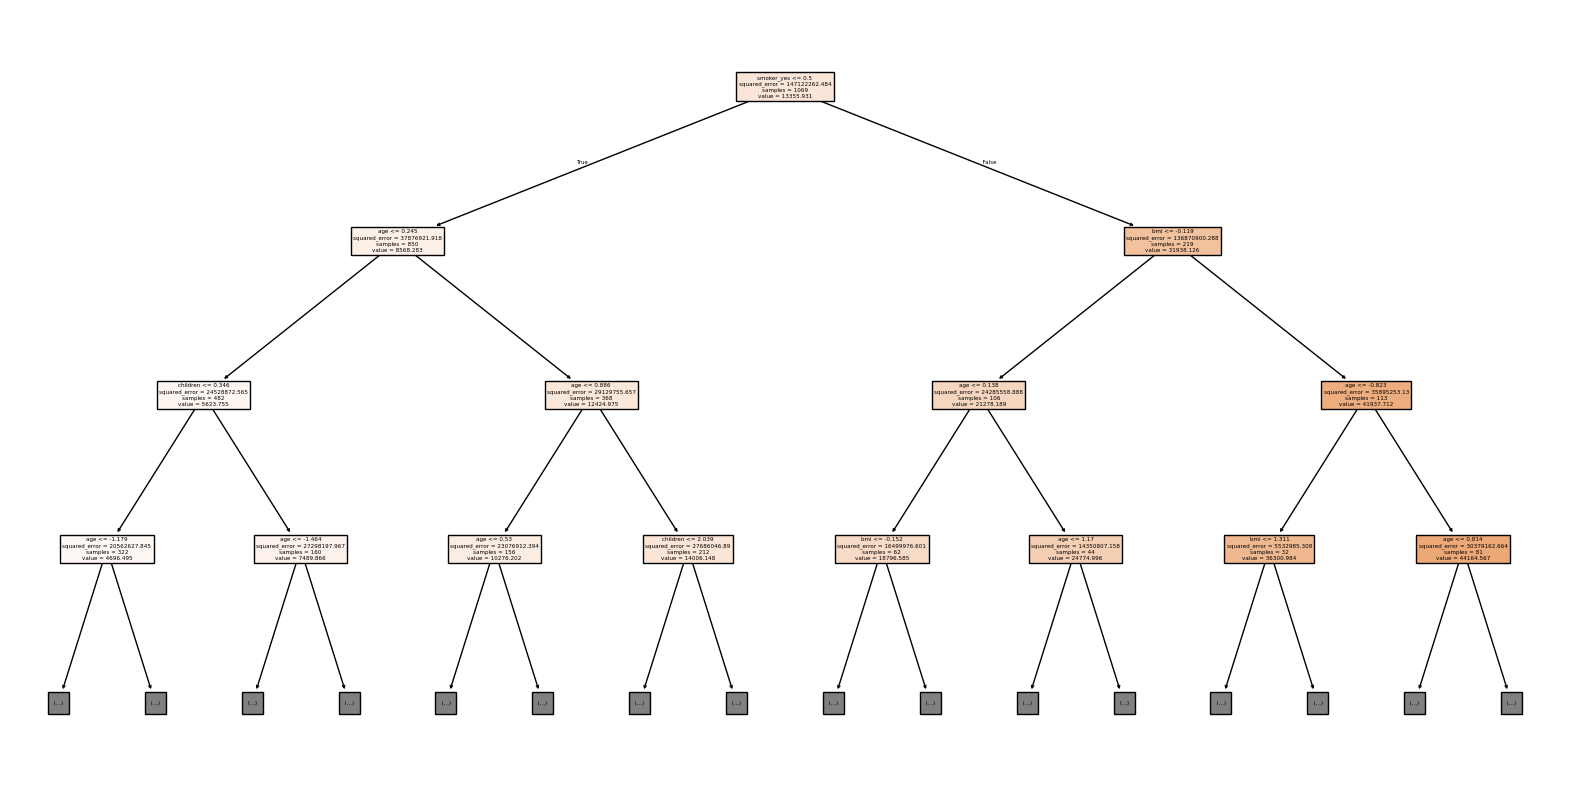

In [45]:
# Visualisation de l'arbre de décision
plt.figure(figsize=(20, 10))
plot_tree(modele_tree, feature_names=X_train_scaled.columns, filled=True, max_depth=3)
plt.show()

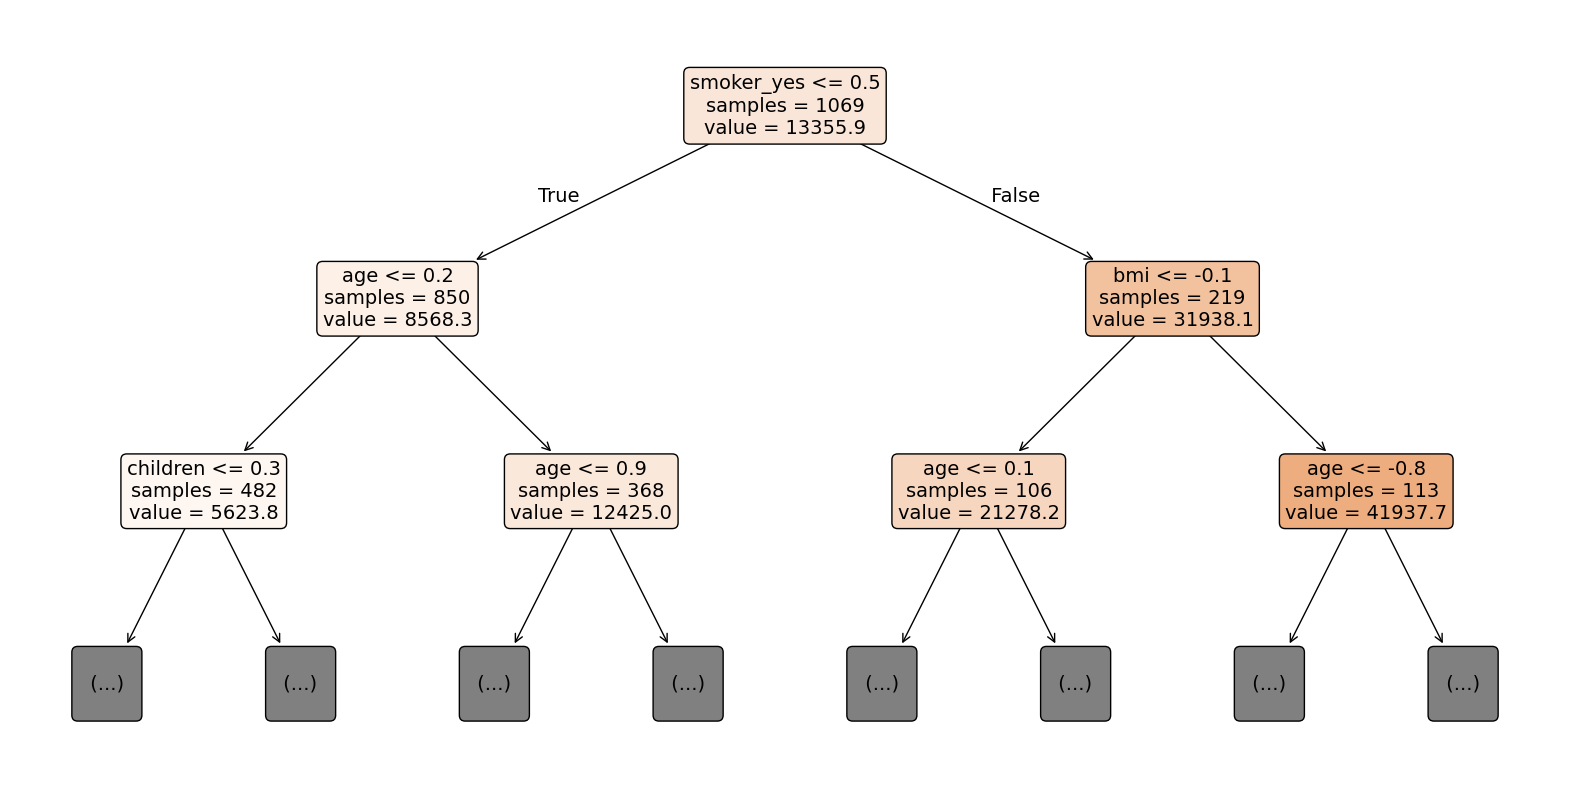

In [46]:
# Visualisation des 2 premiers niveaux de l'arbre de décision,
# avec un texte plus grand et des valeurs arrondies pour plus de lisibilité
plt.figure(figsize=(20, 10))
plot_tree(modele_tree, feature_names=X_train_scaled.columns, filled=True, max_depth=2, fontsize=14, precision=1, rounded=True, impurity=False)
plt.show()

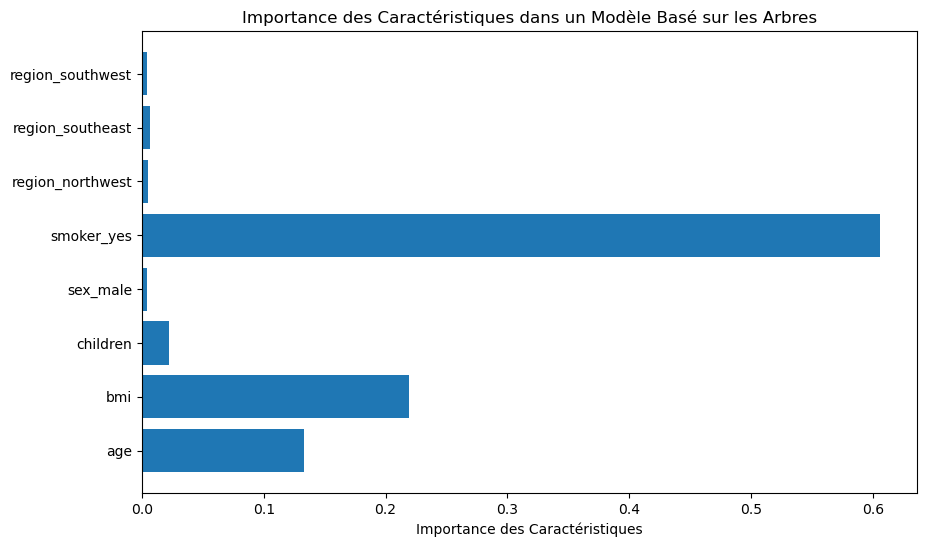

In [47]:
# Affichage de l'importance des caractéristiques
# Récupérer l'importance des caractéristiques pour les modèles basés sur les arbres
importances = modele_tree.feature_importances_  # Importance des caractéristiques pour DecisionTreeRegressor
feature_names = X_train_scaled.columns

# Visualiser l'importance des caractéristiques
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel("Importance des Caractéristiques")
plt.title("Importance des Caractéristiques dans un Modèle Basé sur les Arbres")
plt.show()

Le premier nœud de l'arbre sépare les assurés selon le statut fumeur (smoker_yes), qui est aussi de loin la variable la plus importante (environ 0,60). Les nœuds suivants utilisent l'âge chez les non-fumeurs et l'IMC chez les fumeurs, qui arrivent respectivement en 3ᵉ (environ 0,13) et 2ᵉ position (environ 0,22). Le sexe et la région n'apparaissent pas dans les premiers niveaux, et leur importance est quasiment nulle (inférieure à 0,01).

A noter que les décisions de l'arbre sont cohérentes avec l'EDA et avec la logique médicale. L'arbre commence par distinguer fumeurs et non-fumeurs, dont les frais moyens passent d'environ 8 600 à 31 900. Chez les non-fumeurs, il découpe ensuite selon l'âge, les frais augmentant avec l'âge. Chez les fumeurs, il découpe selon l'IMC : les fumeurs au-delà d'un seuil ont des frais moyens d'environ 42 000, contre 21 000 pour les autres. 

L'IMC apparaît ici plus important que l'âge, contrairement à la régression linéaire. Cela s'explique par la capacité de l'arbre à capturer l'effet de seuil de l'IMC chez les fumeurs, que la régression linéaire, limitée à des effets additifs, ne peut pas modéliser.

## 4) Forêt d’Arbres Décisionnels (Random Forest) : Importance des Caractéristiques

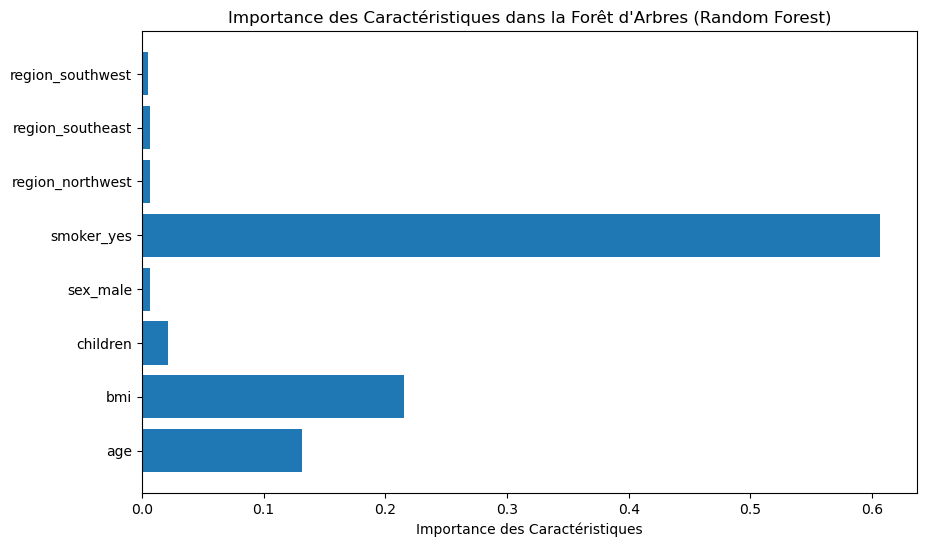

In [48]:
# Affichage de l'importance des caractéristiques dans la Forêt d'Arbres
# Récupérer l'importance des caractéristiques pour la Forêt d'Arbres
importances_rf = modele_rf.feature_importances_
feature_names = X_train_scaled.columns

# Visualiser l'importance des caractéristiques
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances_rf)
plt.xlabel("Importance des Caractéristiques")
plt.title("Importance des Caractéristiques dans la Forêt d'Arbres (Random Forest)")
plt.show()

Les résultats observés précédemment avec l'arbre de décision se confirment pour le Random forest où le tabagisme impacte de façon très importante le montant des frais médicaux engagés. L'age, l'imc et e nombre d'enfants conservant leur classement ensuite.

## 5) Résumé et Comparaison des Modèles

Les trois modèles interprétables désignent le statut fumeur comme la caractéristique dominante : coefficient de +23 750 $ en régression linéaire, premier découpage de l'arbre de décision, et importance d'environ 0,60 dans le Random Forest comme dans l'arbre. Tous s'accordent aussi sur le faible impact du sexe, de la région et du nombre d'enfants.

L'ordre des variables secondaires diffère en revanche. La régression linéaire place l'âge devant l'IMC, alors que l'arbre de décision et le Random Forest placent l'IMC devant l'âge. Cet écart s'explique par la nature des modèles : les arbres exploitent l'effet de seuil de l'IMC chez les fumeurs, alors que la régression linéaire attribue un effet moyen unique à l'IMC pour tous les assurés.

A noter que les modèles à base d'arbres, et en particulier le Random Forest, semblent les mieux adaptés à la structure des données. L'EDA a mis en évidence des relations non linéaires : trois bandes de frais selon l'âge, un effet de seuil de l'IMC autour de 30 et une interaction entre tabac et IMC. Les arbres capturent naturellement ces seuils et interactions par découpages successifs, comme le montre la structure de l'arbre (tabac, puis IMC chez les fumeurs).

La régression linéaire, qui suppose des effets additifs et constants, ne peut pas modéliser l'interaction tabac × IMC. L'arbre de décision seul capture bien la structure, mais son surapprentissage (erreurs ponctuelles très importantes à l'étape 6) le rend moins fiable que le Random Forest, qui lisse ces erreurs en combinant de nombreux arbres. 

En fonction des résultats, quelles caractéristiques ou ajustements pourraient être envisagés pour améliorer les performances ?

On peut envisager plusieurs pistes pour améliorer les performance de nos modèles :

- Créer de nouvelles caractéristiques (feature engineering) : une variable indiquant l'obésité (IMC ≥ 30) et une variable d'interaction « fumeur × obèse » permettraient à la régression linéaire de capturer l'effet de seuil et l'interaction observés en EDA, qu'elle ne peut pas modéliser avec les variables actuelles.
- Simplifier le modèle : le sexe et les régions ont une importance quasiment nulle. On pourrait tester leur suppression, pour vérifier si le modèle conserve ses performances avec moins de variables. Cela simplifierait aussi le formulaire du simulateur Streamlit.
- Limiter le surapprentissage de l'arbre de décision : fixer une profondeur maximale (max_depth) ou un nombre minimum d'observations par feuille.
- Optimiser les hyperparamètres des modèles les plus prometteurs, notamment le nombre d'arbres et leur profondeur pour le Random Forest, et le nombre de voisins pour le KNN.

# Étape 8 : Évaluation des Modèles de Régression

## Métriques d'Évaluation en Régression

## 1) Mean Squared Error (MSE) - Erreur Quadratique Moyenne

In [49]:
# Calcul de la MSE d’un modèle

mse_lr = mean_squared_error(y_test, y_pred_lr)
print("MSE Régression Linéaire :", mse_lr)

mse_knn = mean_squared_error(y_test, y_pred_knn)
print("MSE KNN :", mse_knn)

mse_tree = mean_squared_error(y_test, y_pred_tree)
print("MSE Arbre de Décision :", mse_tree)

mse_rf = mean_squared_error(y_test, y_pred_rf)
print("MSE Random Forest :", mse_rf)


MSE Régression Linéaire : 25868870.525035575
MSE KNN : 43958895.64598949
MSE Arbre de Décision : 43217903.4279362
MSE Random Forest : 16261768.05659835


La MSE s'exprimant en dollars au carré, elle est difficile à interpréter. Nous calculons donc aussi la RMSE (racine de la MSE), qui ramène l'erreur dans l'unité de la cible, en dollars.

In [50]:
# Calcul de la RMSE (racine de la MSE) pour exprimer l'erreur en dollars
print("RMSE Régression Linéaire :", round(mse_lr ** 0.5))
print("RMSE KNN :", round(mse_knn ** 0.5))
print("RMSE Arbre de Décision :", round(mse_tree ** 0.5))
print("RMSE Random Forest :", round(mse_rf ** 0.5))

RMSE Régression Linéaire : 5086
RMSE KNN : 6630
RMSE Arbre de Décision : 6574
RMSE Random Forest : 4033


Le KNN (43,96 millions) et l'arbre de décision (43,22 millions) affichent les MSE les plus élevées.

La régression linéaire obtient une MSE intermédiaire (25,87 millions).

Le Random Forest affiche la MSE la plus faible (16,26 millions), soit une erreur d'environ 4K. C'est près de 37 % de moins que la régression linéaire.

## 2) Erreur Absolue Moyenne (Mean Absolute Error - MAE)

In [51]:
# Calcul de la MAE d’un modèle

mae_lr = mean_absolute_error(y_test, y_pred_lr)
print("MAE Régression Linéaire :", mae_lr)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
print("MAE KNN :", mae_knn)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
print("MAE Arbre de Décision :", mae_tree)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
print("MAE Random Forest :", mae_rf)

MAE Régression Linéaire : 3591.961575450206
MAE KNN : 3771.5380298507466
MAE Arbre de Décision : 3151.89026119403
MAE Random Forest : 2542.7763670024865


Le Random Forest obtient la meilleure MAE : il se trompe en moyenne de 2 543 par assuré. Suivent l'arbre de décision (3 152 ), la régression linéaire (3 592) et le KNN (3 772). Le Random Forest est nettement devant, avec environ 610 d'erreur moyenne de moins que le deuxième.

A noter que pour l'arbre de décision, il est 2ᵉ en MAE mais 3ᵉ en MSE, derrière la régression linéaire. Cela signifie qu'il est précis sur la plupart des assurés, mais qu'il commet quelques erreurs très importantes. La MSE, qui élève les erreurs au carré, pénalise fortement ces grosses erreurs, alors que la MAE les compte normalement. C'est la signature du surapprentissage déjà observée à l'étape 6.

## 3) R² Score (Coefficient de Détermination)

In [52]:
# Calcul du R² Score d’un modèle

r2_lr = r2_score(y_test, y_pred_lr)
print("R² Régression Linéaire :", r2_lr)

r2_knn = r2_score(y_test, y_pred_knn)
print("R² KNN :", r2_knn)

r2_tree = r2_score(y_test, y_pred_tree)
print("R² Arbre de Décision :", r2_tree)

r2_rf = r2_score(y_test, y_pred_rf)
print("R² Random Forest :", r2_rf)

R² Régression Linéaire : 0.820548884144003
R² KNN : 0.695059246292343
R² Arbre de Décision : 0.7001994738195396
R² Random Forest : 0.8871928938403479


Le Random Forest obtient le meilleur R² (0,887) : il explique environ 89 % de la variance des frais médicaux. C'est un bon niveau, cohérent avec ses meilleurs résultats en MSE et en MAE. La régression linéaire suit avec 0,821, soit environ 82 % de la variance expliquée.

L'arbre de décision (0,700) et le KNN (0,695) ont les R² les plus bas : ils n'expliquent qu'environ 70 % de la variance. Pour l'arbre de décision, cela s'explique par le surapprentissage : sans limite de profondeur, il généralise mal sur de nouveaux assurés. Pour le KNN, le calcul des distances donne probablement trop peu de poids au statut fumeur, la variable la plus déterminante, ce qui l'amène à s'appuyer sur des voisins aux frais très différents.

## Interprétation des Résultats

In [53]:
# Organisation des métriques dans un tableau
tableau_metriques = pd.DataFrame({
    "Modèle": ["Régression Linéaire", "KNN", "Arbre de Décision", "Random Forest"],
    "MSE": [mse_lr, mse_knn, mse_tree, mse_rf],
    "MAE": [mae_lr, mae_knn, mae_tree, mae_rf],
    "R²": [r2_lr, r2_knn, r2_tree, r2_rf]
})

tableau_metriques

,Modèle,MSE,MAE,R²
0,Régression Linéaire,2.586887e+07,3591.961575,0.820549
1,KNN,4.395890e+07,3771.538030,0.695059
2,Arbre de Décision,4.321790e+07,3151.890261,0.700199
3,Random Forest,1.626177e+07,2542.776367,0.887193


- Analyse des performances

Le Random Forest a la MSE la plus faible (16,3 millions, soit une erreur d'environ 4K$). Cela ne veut pas dire qu'il est précis pour tous les assurés : la MSE est une moyenne, et quelques grosses erreurs peuvent subsister, notamment sur les fumeurs aux frais élevés.

Le Random Forest a aussi la MAE la plus faible : il se trompe en moyenne de 2.5K$ par assuré. Il est donc le meilleur sur les deux métriques.

Le Random Forest a le R² le plus élevé (0,887) : il explique environ 89 % des variations des frais médicaux. Il est aussi le meilleur en MSE et en MAE.

- Comparaison des modèles

Le Random Forest est le meilleur modèle sur les trois métriques.

Il apparait qeu l'arbre de décision est le plus sensible aux valeurs extrêmes. Il est 2ᵉ en MAE mais 3ᵉ en MSE, derrière la régression linéaire. Il est donc précis pour la plupart des assurés, mais fait quelques très grosses erreurs. Cela confirme son surapprentissage. Les autres modèles gardent un classement stable entre les deux métriques.

## Conclusion des Résultats et Choix du Modèle Optimal

Le Random Forest est le modèle le plus adapté. Il obtient les meilleurs résultats sur toutes les métriques (MAE de 2 543$, R² de 0,887). Il capture bien les effets observés dans l'EDA : l'effet du tabac, l'effet de seuil de l'IMC et l'interaction entre les deux. Il limite aussi le surapprentissage de l'arbre de décision seul.

Pour un assureur, la MAE est la plus utile : elle donne directement l'erreur moyenne en dollars par assuré. La MSE permet de repérer les modèles qui font de grosses erreurs ponctuelles, qui sont risquées pour la tarification. Le R² donne une note globale de la qualité du modèle.

Pour un décideur, la régression linéaire est la plus facile à expliquer : ses coefficients se lisent directement, par exemple « être fumeur ajoute environ 23 750 $ de frais ». Le Random Forest est plus précis, mais il est plus difficile à expliquer. L'importance des variables permet toutefois de montrer ce qui compte le plus dans ses prédictions. 

En conclusion, pour Aegis Health Coverage, on retient le Random Forest pour sa précision et la MAE comme métrique de référence pour comparer les modèles et choisir les réglages lors de l'optimisation. C'est la mesure la plus concrète pour un assureur : elle indique directement, en dollars, de combien le modèle se trompe en moyenne sur les frais d'un assuré.

## Étape 9 : Optimisation du modèle Random Forest

## 1) Introduction

Le Random Forest ayant obtenu la MAE la plus faible, c'est le modèle que nous optimisons. Nous appliquons la solution suivante : réduire la complexité du modèle pour limiter le surapprentissage. Le surapprentissage se repère par un grand écart entre l'erreur sur le jeu d'entraînement et l'erreur sur le jeu de test, mesurée ici avec la MAE.

Les réglages sont choisis en comparant les MAE sur le jeu de test. Cette méthode simple a une limite : le test sert à choisir les réglages, ce qui rend le score final légèrement optimiste.

## 2) Diagnostic du Random Forest de base

In [54]:
# Fonction qui calcule, pour un modèle déjà entraîné, la MAE sur le train et sur le test.
# Un écart important entre les deux (MAE train bien plus faible) signale un surapprentissage.
def evaluer(nom, modele):
    return {
        "Modèle": nom,
        "MAE train": mean_absolute_error(y_train, modele.predict(X_train_scaled)),
        "MAE test": mean_absolute_error(y_test, modele.predict(X_test_scaled))
    }

In [55]:
# Comparaison de la MAE du Random Forest de base sur le train et sur le test,
# pour vérifier s'il présente un surapprentissage
pd.DataFrame([evaluer("Random Forest (base)", modele_rf)]).round(0)

,Modèle,MAE train,MAE test
0,Random Forest (base),1111.0,2543.0


Le Random Forest de base présente un surapprentissage modéré. Sa MAE est de 1111 sur le jeu d'entraînement, contre 2543 sur le jeu de test, soit une erreur environ 2,3 fois plus élevée sur des assurés qu'il n'a jamais vus. Le modèle a donc en partie mémorisé les données d'entraînement. Réduire sa complexité pourrait diminuer cet écart et améliorer ses prédictions sur de nouveaux assurés.

## 3) Réduction de la complexité du modèle

Pour réduire la complexité du Random Forest, on limite la profondeur de ses arbres (max_depth) ou on impose un nombre minimum d'assurés par feuille (min_samples_leaf). Chaque arbre fait ainsi moins de découpages et mémorise moins les cas particuliers.

In [56]:
# Entraînement de plusieurs Random Forest avec des arbres moins complexes :
# - max_depth limite la profondeur de chaque arbre
# - min_samples_leaf impose un nombre minimum d'assurés dans chaque feuille
modele_rf_d4 = RandomForestRegressor(max_depth=4, random_state=42).fit(X_train_scaled, y_train)
modele_rf_d6 = RandomForestRegressor(max_depth=6, random_state=42).fit(X_train_scaled, y_train)
modele_rf_leaf5 = RandomForestRegressor(min_samples_leaf=5, random_state=42).fit(X_train_scaled, y_train)
modele_rf_leaf10 = RandomForestRegressor(min_samples_leaf=10, random_state=42).fit(X_train_scaled, y_train)

# Comparaison avec le Random Forest de base, classée selon la MAE sur le test
pd.DataFrame([
    evaluer("Random Forest (base)", modele_rf),
    evaluer("RF max_depth=4", modele_rf_d4),
    evaluer("RF max_depth=6", modele_rf_d6),
    evaluer("RF min_samples_leaf=5", modele_rf_leaf5),
    evaluer("RF min_samples_leaf=10", modele_rf_leaf10)
]).sort_values("MAE test").round(0)

,Modèle,MAE train,MAE test
4,RF min_samples_leaf=10,2395.0,2175.0
1,RF max_depth=4,2603.0,2214.0
2,RF max_depth=6,2204.0,2224.0
3,RF min_samples_leaf=5,2160.0,2230.0
0,Random Forest (base),1111.0,2543.0


Le réglage min_samples_leaf=10 obtient la MAE la plus faible sur le test (2175), contre 2543 pour le Random Forest de base, soit une amélioration d'environ 14 %. Tous les réglages testés améliorent le modèle de base, avec des MAE test comprises entre 2175 et 2230.

L'écart entre le train et le test a presque disparu. Pour le modèle retenu, la MAE est de 2395 sur le train et de 2175 sur le test. En imposant au moins 10 assurés par feuille, les arbres ne peuvent plus mémoriser des cas individuels. Le modèle est un peu moins précis sur les données d'entraînement, mais il généralise mieux sur de nouveaux assurés, ce qui est l'objectif d'un moteur de tarification.

In [57]:
# Test d'un nombre minimum d'assurés par feuille plus élevé,
# pour vérifier si l'amélioration continue au-delà de 10
modele_rf_leaf20 = RandomForestRegressor(min_samples_leaf=20, random_state=42).fit(X_train_scaled, y_train)
pd.DataFrame([evaluer("RF min_samples_leaf=20", modele_rf_leaf20)]).round(0)

,Modèle,MAE train,MAE test
0,RF min_samples_leaf=20,2627.0,2200.0


Un test complémentaire avec min_samples_leaf=20 donne une MAE test plus élevée (2200) et une MAE train qui augmente (2627) : le modèle devient trop simple et commence à sous-apprendre. La valeur de 10 constitue donc le meilleur compromis.

## 4) Choix du modèle final

In [58]:
# Sélection du modèle final : le Random Forest avec au moins 10 assurés par feuille,
# qui a obtenu la MAE la plus faible sur le test à l'étape 9.2
modele_final = modele_rf_leaf10

# Affichage de ses performances finales sur le jeu de test
y_pred_final = modele_final.predict(X_test_scaled)
print("MAE finale :", round(mean_absolute_error(y_test, y_pred_final)), "$")

MAE finale : 2175 $


Conclusion : 

L'optimisation effectuée a amélioré le Random Forest. En imposant au moins 10 assurés par feuille, la MAE sur le test passe de 2543 à 2175, soit une baisse d'environ 14 %. Le surapprentissage du modèle de base a disparu : les erreurs sur le train et sur le test sont désormais proches.


In [59]:
# Calcul des 3 métriques du modèle final
y_pred_final = modele_final.predict(X_test_scaled)
print("MAE  :", round(mean_absolute_error(y_test, y_pred_final)), "$")
print("RMSE :", round(mean_squared_error(y_test, y_pred_final) ** 0.5), "$")
print("R²   :", round(r2_score(y_test, y_pred_final), 3))

MAE  : 2175 $
RMSE : 3428 $
R²   : 0.918
